Using device: cuda


Epoch 1/20: 100%|██████████| 825/825 [04:30<00:00,  3.05it/s]


Epoch 1 | Train Loss: 1.1037 | Val Loss: 1.1040 | Val Acc: 0.3244
✅ Saved best model!


Epoch 2/20: 100%|██████████| 825/825 [04:24<00:00,  3.12it/s]


Epoch 2 | Train Loss: 1.0960 | Val Loss: 1.1064 | Val Acc: 0.3272
✅ Saved best model!


...

Epoch 18 | Train Loss: 0.8367 | Val Loss: 1.4709 | Val Acc: 0.3222


Epoch 19/20: 100%|██████████| 825/825 [03:02<00:00,  4.51it/s]


Epoch 19 | Train Loss: 0.8225 | Val Loss: 1.5020 | Val Acc: 0.3233


Epoch 20/20: 100%|██████████| 825/825 [03:03<00:00,  4.49it/s]


Epoch 20 | Train Loss: 0.8041 | Val Loss: 1.5867 | Val Acc: 0.3206


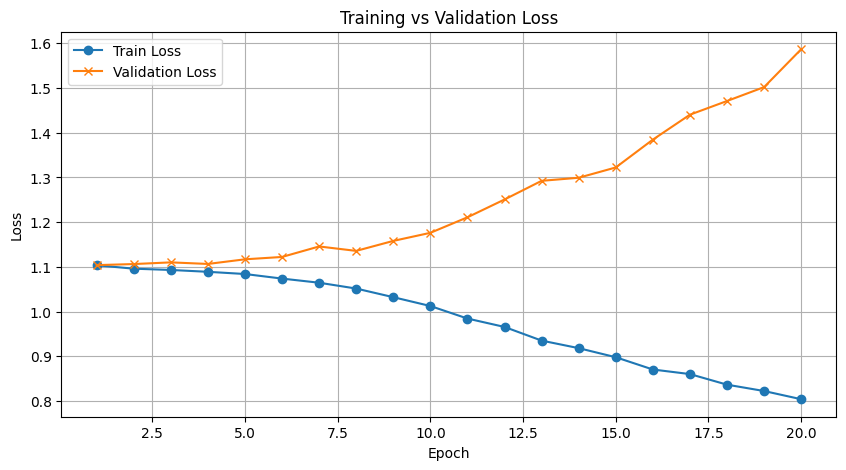


========== FINAL REPORT ==========
              precision    recall  f1-score   support

          de       0.34      0.65      0.44       600
          fr       0.35      0.18      0.24       600
          it       0.33      0.19      0.24       600

    accuracy                           0.34      1800
   macro avg       0.34      0.34      0.31      1800
weighted avg       0.34      0.34      0.31      1800

Confusion Matrix:
 [[388  92 120]
 [381 108 111]
 [377 110 113]]


In [12]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

# -------------------------
# Config
# -------------------------
NPZ_PATH = "mfcc_lstm_sequences.npz"  # Replace with your npz file path
CHECKPOINT_DIR = "multihead_lstm_checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 1e-3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_WORKERS = 0  # safer for Windows
PIN_MEMORY = False

print("Using device:", DEVICE)

# -------------------------
# Load NPZ data
# -------------------------
data = np.load(NPZ_PATH)
X = data["X"]  # shape [num_samples, time_steps, n_mfcc]
y = data["y"]  # array of string labels

# Encode labels to integers
le = LabelEncoder()
y = le.fit_transform(y)
num_classes = len(le.classes_)

# Train/Validation split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.12, random_state=42, stratify=y
)

# -------------------------
# Dataset
# -------------------------
class MFCCSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = [torch.tensor(seq, dtype=torch.float32) for seq in sequences]
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.sequences[idx], self.labels[idx]

# Collate function for variable-length sequences
def collate_fn(batch):
    sequences, labels = zip(*batch)
    lengths = torch.tensor([len(seq) for seq in sequences], dtype=torch.long)
    padded = nn.utils.rnn.pad_sequence(sequences, batch_first=True)
    return padded.to(DEVICE), lengths.to(DEVICE), torch.tensor(labels, device=DEVICE)

train_loader = DataLoader(
    MFCCSequenceDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    MFCCSequenceDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# -------------------------
# Multi-Head LSTM Model
# -------------------------
class MultiHeadLSTM(nn.Module):
    def __init__(self, n_mfcc, hidden_size, num_layers, num_heads, num_classes, bidirectional=True):
        super().__init__()
        self.num_heads = num_heads
        self.branches = nn.ModuleList([
            nn.LSTM(
                input_size=n_mfcc,
                hidden_size=hidden_size,
                num_layers=num_layers,
                batch_first=True,
                bidirectional=bidirectional
            )
            for _ in range(num_heads)
        ])
        self.fcs = nn.ModuleList([
            nn.Linear(hidden_size * (2 if bidirectional else 1), num_classes)
            for _ in range(num_heads)
        ])
        self.final_fc = nn.Linear(num_classes * num_heads, num_classes)
        self.softmax = nn.Softmax(dim=-1)

    def forward(self, x, lengths):
        branch_outputs = []
        for i, lstm in enumerate(self.branches):
            packed = nn.utils.rnn.pack_padded_sequence(
                x, lengths.cpu(), batch_first=True, enforce_sorted=False
            )
            out, _ = lstm(packed)
            out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
            idx = (lengths - 1).view(-1, 1, 1).expand(-1, 1, out.size(2))
            last_out = out.gather(1, idx).squeeze(1)
            logits = self.fcs[i](last_out)
            branch_outputs.append(logits)
        concat_out = torch.cat(branch_outputs, dim=-1)
        final_logits = self.final_fc(concat_out)
        return final_logits, self.softmax(final_logits)

# -------------------------
# Initialize model
# -------------------------
n_mfcc = X.shape[2]  # number of MFCC features
model = MultiHeadLSTM(n_mfcc=n_mfcc, hidden_size=128, num_layers=1, num_heads=3, num_classes=num_classes)
model.to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.CrossEntropyLoss()

# -------------------------
# Training Loop
# -------------------------
train_losses = []
val_losses = []
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0.0

    for X_batch, lengths, y_batch in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS}"):
        optimizer.zero_grad()
        logits, _ = model(X_batch, lengths)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0.0
    preds, trues = [], []

    with torch.no_grad():
        for X_batch, lengths, y_batch in val_loader:
            logits, _ = model(X_batch, lengths)
            loss = criterion(logits, y_batch)
            total_val_loss += loss.item()
            pred = torch.argmax(logits, dim=1)
            preds.extend(pred.cpu().tolist())
            trues.extend(y_batch.cpu().tolist())

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)
    val_acc = accuracy_score(trues, preds)

    print(f"Epoch {epoch} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), os.path.join(CHECKPOINT_DIR, "best.pt"))
        print("✅ Saved best model!")

# -------------------------
# Plot training vs validation loss
# -------------------------
plt.figure(figsize=(10,5))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), val_losses, marker='x', label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

# -------------------------
# Final Evaluation
# -------------------------
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "best.pt")))
model.eval()
preds, trues = [], []

with torch.no_grad():
    for X_batch, lengths, y_batch in val_loader:
        logits, _ = model(X_batch.to(DEVICE), lengths.to(DEVICE))
        pred = torch.argmax(logits, dim=1)
        preds.extend(pred.cpu().tolist())
        trues.extend(y_batch.tolist())

print("\n========== FINAL REPORT ==========")
print(classification_report(trues, preds, target_names=list(le.classes_)))
print("Confusion Matrix:\n", confusion_matrix(trues, preds))
